Connected to Python 3.13.7

 # EmoLearn: Check-In 2
 ## Baseline Model and Initial Experimental Evaluation

 **Author:** Rui Wu
 **Course:** CS466 – Multimodal Interaction and Learning

 Steps:
 1. Extract features from all 9,068 videos (one-time, saves to disk)
 2. Baseline 1: Geometric-only MLP
 3. Baseline 2: Appearance-only MLP (ResNet-18 embeddings)
 4. Improvement 1: Early fusion (both modalities)
 5. Improvement 2: Class-weighted training
 6. Evaluation and comparison

 ## 1. Setup and Configuration

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report
)

# Device setup: prefer MPS (Apple Silicon GPU) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple M4 GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Paths -- UPDATE THESE
DAISEE_ROOT = "/Users/apple/Desktop/DAiSEE"
DATA_DIR = os.path.join(DAISEE_ROOT, "DataSet")
LABEL_DIR = os.path.join(DAISEE_ROOT, "Labels")
FEATURE_DIR = os.path.join(DAISEE_ROOT, "Features")  # where we save extracted features
os.makedirs(FEATURE_DIR, exist_ok=True)

# MediaPipe setup
import mediapipe as mp
BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Download models if needed
import urllib.request
FACE_DETECTOR_MODEL = "blaze_face_short_range.tflite"
FACE_LANDMARKER_MODEL = "face_landmarker.task"

for fname, url in [
    (FACE_DETECTOR_MODEL, "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"),
    (FACE_LANDMARKER_MODEL, "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"),
]:
    if not os.path.exists(fname):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)

# Hyperparameters
NUM_FRAMES = 10       # frames to sample per video
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30
RESNET_DIM = 512      # ResNet-18 embedding size
GEOM_DIM = 6          # [pitch, yaw, roll, L_EAR, R_EAR, MAR]

# Load labels
train_labels = pd.read_csv(os.path.join(LABEL_DIR, "TrainLabels.csv"))
val_labels = pd.read_csv(os.path.join(LABEL_DIR, "ValidationLabels.csv"))
test_labels = pd.read_csv(os.path.join(LABEL_DIR, "TestLabels.csv"))

print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")

Using Apple M4 GPU (MPS)
Train: 5358, Val: 1429, Test: 1784


 ## 2. Feature Extraction (run once, saves to disk)

 For each video:
 - Sample 10 frames
 - Face detection → crop → ResNet-18 embedding (appearance)
 - Face landmarks → head pose + EAR + MAR (geometric)
 - Average across frames → one feature vector per video

 This takes ~1-2 hours on M4. Once done, we load from disk.

In [ ]:
def get_video_path(clip_id, data_dir, split="Train"):
    """Reconstruct nested DAiSEE path from ClipID."""
    if "/" in clip_id or "\\" in clip_id:
        return os.path.join(data_dir, split, clip_id)
    clip_name = clip_id.replace(".avi", "")
    subject_id = clip_name[:6]
    return os.path.join(data_dir, split, subject_id, clip_name, clip_name + ".avi")


def extract_frames(video_path, num_frames=10):
    """Extract uniformly spaced frames from a video."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    
    indices = np.linspace(0, total - 1, min(num_frames, total), dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    cap.release()
    return frames


# Landmark indices for geometric features
POSE_LANDMARKS = [1, 33, 263, 61, 291, 199]
LEFT_EYE = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
MOUTH = [61, 291, 0, 17]


def compute_geometric(landmarks, w, h):
    """Compute [pitch, yaw, roll, L_EAR, R_EAR, MAR] from landmarks."""
    def ear(eye_idx):
        pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in eye_idx]
        v1 = np.linalg.norm(np.array(pts[1]) - np.array(pts[5]))
        v2 = np.linalg.norm(np.array(pts[2]) - np.array(pts[4]))
        hz = np.linalg.norm(np.array(pts[0]) - np.array(pts[3]))
        return (v1 + v2) / (2.0 * hz) if hz > 0 else 0.0
    
    def mar():
        pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in MOUTH]
        v = np.linalg.norm(np.array(pts[2]) - np.array(pts[3]))
        hz = np.linalg.norm(np.array(pts[0]) - np.array(pts[1]))
        return v / hz if hz > 0 else 0.0
    
    # Head pose via solvePnP
    model_pts = np.array([
        (0, 0, 0), (-225, 170, -135), (225, 170, -135),
        (-150, -150, -125), (150, -150, -125), (0, -330, -65)
    ], dtype=np.float64)
    img_pts = np.array([(landmarks[i].x * w, landmarks[i].y * h) for i in POSE_LANDMARKS], dtype=np.float64)
    cam = np.array([[w, 0, w/2], [0, w, h/2], [0, 0, 1]], dtype=np.float64)
    
    ok, rvec, tvec = cv2.solvePnP(model_pts, img_pts, cam, np.zeros((4,1)), flags=cv2.SOLVEPNP_ITERATIVE)
    if not ok:
        return [0.0] * 6
    
    rmat, _ = cv2.Rodrigues(rvec)
    pmat = np.hstack([rmat, tvec])
    _, _, _, _, _, _, euler = cv2.decomposeProjectionMatrix(np.vstack([pmat, [0,0,0,1]])[:3,:])
    pitch, yaw, roll = euler.flatten()[:3]
    
    return [pitch, yaw, roll, ear(LEFT_EYE), ear(RIGHT_EYE), mar()]


def extract_all_features(label_df, data_dir, split_name, feature_dir,
                          resnet, transform, face_det, face_lm):
    """
    Extract appearance (ResNet-18) and geometric features for all videos in a split.
    Saves results to .npy files. Skips if already extracted.
    """
    app_path = os.path.join(feature_dir, f"{split_name}_appearance.npy")
    geo_path = os.path.join(feature_dir, f"{split_name}_geometric.npy")
    lbl_path = os.path.join(feature_dir, f"{split_name}_labels.npy")
    idx_path = os.path.join(feature_dir, f"{split_name}_valid_idx.npy")
    
    # Skip if already extracted
    if all(os.path.exists(p) for p in [app_path, geo_path, lbl_path, idx_path]):
        print(f"{split_name}: Loading from cache...")
        return (np.load(app_path), np.load(geo_path),
                np.load(lbl_path), np.load(idx_path))
    
    print(f"{split_name}: Extracting features from {len(label_df)} videos...")
    
    all_app = []
    all_geo = []
    all_lbl = []
    valid_idx = []
    
    start = time.time()
    
    for i in range(len(label_df)):
        row = label_df.iloc[i]
        vpath = get_video_path(row["ClipID"], data_dir, split=split_name)
        
        if not os.path.exists(vpath):
            continue
        
        frames = extract_frames(vpath, NUM_FRAMES)
        if len(frames) == 0:
            continue
        
        frame_app = []  # ResNet embeddings per frame
        frame_geo = []  # geometric features per frame
        
        for frame in frames:
            h, w, _ = frame.shape
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # --- Appearance: face crop → ResNet-18 embedding ---
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            det_result = face_det.detect(mp_img)
            
            if det_result.detections:
                bb = det_result.detections[0].bounding_box
                x1 = max(0, bb.origin_x - int(bb.width * 0.1))
                y1 = max(0, bb.origin_y - int(bb.height * 0.1))
                x2 = min(w, bb.origin_x + bb.width + int(bb.width * 0.1))
                y2 = min(h, bb.origin_y + bb.height + int(bb.height * 0.1))
                crop = rgb[y1:y2, x1:x2]
                if crop.size > 0:
                    crop = cv2.resize(crop, (224, 224))
                else:
                    crop = np.zeros((224, 224, 3), dtype=np.uint8)
            else:
                # Fallback: center crop
                crop = cv2.resize(rgb, (224, 224))
            
            # ResNet embedding
            inp = transform(crop).unsqueeze(0)
            with torch.no_grad():
                emb = resnet(inp).squeeze().numpy()
            frame_app.append(emb)
            
            # Geometriclandmarks: head pose + EAR + MAR
            lm_result = face_lm.detect(mp_img)
            if lm_result.face_landmarks:
                geo = compute_geometric(lm_result.face_landmarks[0], w, h)
            else:
                geo = [0.0] * GEOM_DIM
            frame_geo.append(geo)
        
        # Average across frames (temporal pooling)
        avg_app = np.mean(frame_app, axis=0)   # (512,)
        avg_geo = np.mean(frame_geo, axis=0)   # (6,)
        
        all_app.append(avg_app)
        all_geo.append(avg_geo)
        
        # Labels: use Engagement as primary target (most studied in DAiSEE)
        all_lbl.append([row["Boredom"], row["Engagement"], row["Confusion"], row["Frustration "]])
        valid_idx.append(i)
        
        if (i + 1) % 200 == 0:
            elapsed = time.time() - start
            rate = (i + 1) / elapsed
            remaining = (len(label_df) - i - 1) / rate
            print(f"  {i+1}/{len(label_df)} ({rate:.1f} vid/s, ~{remaining/60:.0f} min remaining)")
    
    all_app = np.array(all_app, dtype=np.float32)
    all_geo = np.array(all_geo, dtype=np.float32)
    all_lbl = np.array(all_lbl, dtype=np.int64)
    valid_idx = np.array(valid_idx, dtype=np.int64)
    
    np.save(app_path, all_app)
    np.save(geo_path, all_geo)
    np.save(lbl_path, all_lbl)
    np.save(idx_path, valid_idx)
    
    elapsed = time.time() - start
    print(f"  Done: {len(all_app)} videos in {elapsed/60:.1f} min. Saved to {feature_dir}/")
    
    return all_app, all_geo, all_lbl, valid_idx


# --- Setup ResNet-18 as feature extractor ---
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()  # remove classification head → outputs 512-dim
resnet.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Setup MediaPipe ---
fd_options = FaceDetectorOptions(
    base_options=BaseOptions(model_asset_path=FACE_DETECTOR_MODEL),
    running_mode=VisionRunningMode.IMAGE, min_detection_confidence=0.5)
fl_options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=FACE_LANDMARKER_MODEL),
    running_mode=VisionRunningMode.IMAGE, num_faces=1)

face_det = FaceDetector.create_from_options(fd_options)
face_lm = FaceLandmarker.create_from_options(fl_options)

# --- Run extraction for all splits ---
train_app, train_geo, train_lbl, train_idx = extract_all_features(
    train_labels, DATA_DIR, "Train", FEATURE_DIR, resnet, transform, face_det, face_lm)

val_app, val_geo, val_lbl, val_idx = extract_all_features(
    val_labels, DATA_DIR, "Validation", FEATURE_DIR, resnet, transform, face_det, face_lm)

test_app, test_geo, test_lbl, test_idx = extract_all_features(
    test_labels, DATA_DIR, "Test", FEATURE_DIR, resnet, transform, face_det, face_lm)

# Cleanup
face_det.close()
face_lm.close()

print(f"\n=== Feature Shapes ===")
print(f"Train: app={train_app.shape}, geo={train_geo.shape}, lbl={train_lbl.shape}")
print(f"Val:   app={val_app.shape}, geo={val_geo.shape}, lbl={val_lbl.shape}")
print(f"Test:  app={test_app.shape}, geo={test_geo.shape}, lbl={test_lbl.shape}")

I0000 00:00:1775107123.164988 20584298 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775107123.170043 20584302 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775107123.171602 20584315 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775107123.177964 20584315 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1775107123.178896 20584319 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775107123.188501 20584318 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Train: Extracting features from 5358 videos...
  200/5358 (4.5 vid/s, ~19 min remaining)
  400/5358 (4.5 vid/s, ~18 min remaining)
  600/5358 (4.6 vid/s, ~17 min remaining)
  800/5358 (4.6 vid/s, ~17 min remaining)
  1000/5358 (4.6 vid/s, ~16 min remaining)
  1200/5358 (4.5 vid/s, ~15 min remaining)
  1400/5358 (4.5 vid/s, ~15 min remaining)
  1600/5358 (4.8 vid/s, ~13 min remaining)
  1800/5358 (4.7 vid/s, ~12 min remaining)
  2000/5358 (4.7 vid/s, ~12 min remaining)


[mpeg4 @ 0x322507920] I cbpy damaged at 16 8
[mpeg4 @ 0x322507920] Error at MB: 344


  2200/5358 (4.7 vid/s, ~11 min remaining)
  2400/5358 (4.7 vid/s, ~11 min remaining)
  2600/5358 (4.7 vid/s, ~10 min remaining)
  2800/5358 (4.7 vid/s, ~9 min remaining)
  3200/5358 (5.1 vid/s, ~7 min remaining)
  3400/5358 (5.0 vid/s, ~6 min remaining)
  3600/5358 (5.0 vid/s, ~6 min remaining)
  3800/5358 (5.0 vid/s, ~5 min remaining)
  4000/5358 (4.9 vid/s, ~5 min remaining)
  4200/5358 (4.9 vid/s, ~4 min remaining)
  4400/5358 (4.9 vid/s, ~3 min remaining)
  4800/5358 (5.0 vid/s, ~2 min remaining)
  5200/5358 (5.1 vid/s, ~1 min remaining)
  Done: 4852 videos in 17.7 min. Saved to /Users/apple/Desktop/DAiSEE/Features/
Validation: Extracting features from 1429 videos...
  200/1429 (4.6 vid/s, ~4 min remaining)
  400/1429 (4.6 vid/s, ~4 min remaining)
  600/1429 (4.6 vid/s, ~3 min remaining)
  800/1429 (4.6 vid/s, ~2 min remaining)
  1000/1429 (4.6 vid/s, ~2 min remaining)
  1200/1429 (4.6 vid/s, ~1 min remaining)
  1400/1429 (4.6 vid/s, ~0 min remaining)
  Done: 1429 videos in 5.1 mi

 ## 3. PyTorch Dataset and DataLoaders

In [ ]:
# We focus on Engagement (column index 1) as the primary classification target.
# This is the most studied label in DAiSEE literature.
TARGET_COL = 1  # 0=Boredom, 1=Engagement, 2=Confusion, 3=Frustration
TARGET_NAME = "Engagement"

class DAiSEEDataset(Dataset):
    """PyTorch Dataset for pre-extracted DAiSEE features."""
    
    def __init__(self, app_features, geo_features, labels, target_col=1):
        self.app = torch.tensor(app_features, dtype=torch.float32)
        self.geo = torch.tensor(geo_features, dtype=torch.float32)
        self.labels = torch.tensor(labels[:, target_col], dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.app[idx], self.geo[idx], self.labels[idx]


train_ds = DAiSEEDataset(train_app, train_geo, train_lbl, TARGET_COL)
val_ds = DAiSEEDataset(val_app, val_geo, val_lbl, TARGET_COL)
test_ds = DAiSEEDataset(test_app, test_geo, test_lbl, TARGET_COL)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Class distribution
train_counts = Counter(train_ds.labels.numpy())
print(f"\n{TARGET_NAME} class distribution (Train):")
for level in sorted(train_counts.keys()):
    print(f"  Level {level}: {train_counts[level]} ({train_counts[level]/len(train_ds)*100:.1f}%)")


Engagement class distribution (Train):
  Level 0: 33 (0.7%)
  Level 1: 201 (4.1%)
  Level 2: 2474 (51.0%)
  Level 3: 2144 (44.2%)


 ## 4. Model Definitions

In [ ]:
class GeometricClassifier(nn.Module):
    """Baseline 1: MLP on geometric features only."""
    def __init__(self, input_dim=6, num_classes=4, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, num_classes)
        )
    
    def forward(self, app, geo):
        return self.net(geo)  # ignores appearance


class AppearanceClassifier(nn.Module):
    """Baseline 2: MLP on ResNet-18 appearance embeddings only."""
    def __init__(self, input_dim=512, num_classes=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, app, geo):
        return self.net(app)  # ignores geometric


class EarlyFusionClassifier(nn.Module):
    """Improvement: Concatenate both modalities before classification."""
    def __init__(self, app_dim=512, geo_dim=6, num_classes=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(app_dim + geo_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(0.3),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, app, geo):
        x = torch.cat([app, geo], dim=1)
        return self.net(x)


class LateFusionClassifier(nn.Module):
    """Improvement: Separate branches merged at decision level."""
    def __init__(self, app_dim=512, geo_dim=6, num_classes=4):
        super().__init__()
        self.app_branch = nn.Sequential(
            nn.Linear(app_dim, 64), nn.ReLU(), nn.Dropout(0.3))
        self.geo_branch = nn.Sequential(
            nn.Linear(geo_dim, 32), nn.ReLU(), nn.Dropout(0.3))
        self.classifier = nn.Sequential(
            nn.Linear(64 + 32, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    
    def forward(self, app, geo):
        a = self.app_branch(app)
        g = self.geo_branch(geo)
        return self.classifier(torch.cat([a, g], dim=1))

 ## 5. Training and Evaluation Functions

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS,
                lr=LEARNING_RATE, class_weights=None, device=device):
    """Train a model and return training history."""
    model = model.to(device)
    
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    best_state = None
    
    for epoch in range(num_epochs):
        # --- Train ---
        model.train()
        total_loss, correct, total = 0, 0, 0
        for app, geo, labels in train_loader:
            app, geo, labels = app.to(device), geo.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(app, geo)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        
        train_loss = total_loss / total
        train_acc = correct / total
        
        # --- Validate ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for app, geo, labels in val_loader:
                app, geo, labels = app.to(device), geo.to(device), labels.to(device)
                outputs = model(app, geo)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * labels.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs}: "
                  f"Train {train_acc:.4f} | Val {val_acc:.4f} | LR {optimizer.param_groups[0]['lr']:.6f}")
    
    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(device)
    
    print(f"  Best val accuracy: {best_val_acc:.4f}")
    return model, history


def evaluate_model(model, test_loader, device=device):
    """Evaluate model on test set, return predictions and metrics."""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for app, geo, labels in test_loader:
            app, geo = app.to(device), geo.to(device)
            outputs = model(app, geo)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "predictions": all_preds,
        "labels": all_labels,
        "report": classification_report(all_labels, all_preds, zero_division=0)
    }

 ## 6. Run Experiments

In [ ]:
results = {}

# --- Baseline 1: Geometric Only ---
print("=" * 60)
print("Baseline 1: Geometric Features Only")
print("=" * 60)
geo_model = GeometricClassifier(input_dim=GEOM_DIM, num_classes=4)
geo_model, geo_hist = train_model(geo_model, train_loader, val_loader)
geo_results = evaluate_model(geo_model, test_loader)
results["Geometric Only"] = {"history": geo_hist, "metrics": geo_results}
print(f"  Test Accuracy: {geo_results['accuracy']:.4f}")
print(f"  Test F1 (macro): {geo_results['f1_macro']:.4f}")

Baseline 1: Geometric Features Only
  Epoch   1/30: Train 0.4536 | Val 0.3443 | LR 0.001000
  Epoch  10/30: Train 0.5128 | Val 0.4906 | LR 0.001000
  Epoch  20/30: Train 0.5060 | Val 0.5528 | LR 0.000500
  Epoch  30/30: Train 0.5113 | Val 0.5647 | LR 0.000125
  Best val accuracy: 0.5689
  Test Accuracy: 0.5183
  Test F1 (macro): 0.1707


In [ ]:
# --- Baseline 2: Appearance Only ---
print("=" * 60)
print("Baseline 2: Appearance Features Only (ResNet-18)")
print("=" * 60)
app_model = AppearanceClassifier(input_dim=RESNET_DIM, num_classes=4)
app_model, app_hist = train_model(app_model, train_loader, val_loader)
app_results = evaluate_model(app_model, test_loader)
results["Appearance Only"] = {"history": app_hist, "metrics": app_results}
print(f"  Test Accuracy: {app_results['accuracy']:.4f}")
print(f"  Test F1 (macro): {app_results['f1_macro']:.4f}")

Baseline 2: Appearance Features Only (ResNet-18)
  Epoch   1/30: Train 0.5031 | Val 0.5913 | LR 0.001000
  Epoch  10/30: Train 0.5921 | Val 0.5101 | LR 0.001000
  Epoch  20/30: Train 0.6148 | Val 0.5437 | LR 0.000500
  Epoch  30/30: Train 0.6286 | Val 0.5500 | LR 0.000125
  Best val accuracy: 0.5913
  Test Accuracy: 0.5568
  Test F1 (macro): 0.2577


In [ ]:
# --- Improvement 1: Early Fusion ---
print("=" * 60)
print("Improvement 1: Early Fusion")
print("=" * 60)
fusion_model = EarlyFusionClassifier(app_dim=RESNET_DIM, geo_dim=GEOM_DIM, num_classes=4)
fusion_model, fusion_hist = train_model(fusion_model, train_loader, val_loader)
fusion_results = evaluate_model(fusion_model, test_loader)
results["Early Fusion"] = {"history": fusion_hist, "metrics": fusion_results}
print(f"  Test Accuracy: {fusion_results['accuracy']:.4f}")
print(f"  Test F1 (macro): {fusion_results['f1_macro']:.4f}")

Improvement 1: Early Fusion
  Epoch   1/30: Train 0.5019 | Val 0.5521 | LR 0.001000
  Epoch  10/30: Train 0.6101 | Val 0.5612 | LR 0.000500
  Epoch  20/30: Train 0.6247 | Val 0.5493 | LR 0.000250
  Epoch  30/30: Train 0.6317 | Val 0.5549 | LR 0.000063
  Best val accuracy: 0.5843
  Test Accuracy: 0.4908
  Test F1 (macro): 0.2492


In [ ]:
# --- Improvement 2: Early Fusion + Class Weights ---
print("=" * 60)
print("Improvement 2: Early Fusion + Class Weighting")
print("=" * 60)

# Compute class weights (inverse frequency)
counts = Counter(train_ds.labels.numpy())
total_samples = sum(counts.values())
class_weights = torch.tensor(
    [total_samples / (len(counts) * counts[c]) for c in sorted(counts.keys())],
    dtype=torch.float32
)
print(f"  Class weights: {class_weights.tolist()}")

weighted_model = EarlyFusionClassifier(app_dim=RESNET_DIM, geo_dim=GEOM_DIM, num_classes=4)
weighted_model, weighted_hist = train_model(
    weighted_model, train_loader, val_loader, class_weights=class_weights)
weighted_results = evaluate_model(weighted_model, test_loader)
results["Early Fusion + Weights"] = {"history": weighted_hist, "metrics": weighted_results}
print(f"  Test Accuracy: {weighted_results['accuracy']:.4f}")
print(f"  Test F1 (macro): {weighted_results['f1_macro']:.4f}")

Improvement 2: Early Fusion + Class Weighting
  Class weights: [36.75757598876953, 6.034825801849365, 0.4902991056442261, 0.5657649040222168]
  Epoch   1/30: Train 0.4017 | Val 0.4696 | LR 0.001000
  Epoch  10/30: Train 0.4639 | Val 0.3926 | LR 0.000500
  Epoch  20/30: Train 0.4738 | Val 0.4381 | LR 0.000250
  Epoch  30/30: Train 0.4957 | Val 0.3989 | LR 0.000063
  Best val accuracy: 0.4696
  Test Accuracy: 0.4347
  Test F1 (macro): 0.2474


In [ ]:
# --- Improvement 3: Late Fusion + Class Weights ---
print("=" * 60)
print("Improvement 3: Late Fusion + Class Weighting")
print("=" * 60)
late_model = LateFusionClassifier(app_dim=RESNET_DIM, geo_dim=GEOM_DIM, num_classes=4)
late_model, late_hist = train_model(
    late_model, train_loader, val_loader, class_weights=class_weights)
late_results = evaluate_model(late_model, test_loader)
results["Late Fusion + Weights"] = {"history": late_hist, "metrics": late_results}
print(f"  Test Accuracy: {late_results['accuracy']:.4f}")
print(f"  Test F1 (macro): {late_results['f1_macro']:.4f}")

Improvement 3: Late Fusion + Class Weighting
  Epoch   1/30: Train 0.3244 | Val 0.3618 | LR 0.001000
  Epoch  10/30: Train 0.4629 | Val 0.4822 | LR 0.000500
  Epoch  20/30: Train 0.4911 | Val 0.5178 | LR 0.000125
  Epoch  30/30: Train 0.4736 | Val 0.5059 | LR 0.000063
  Best val accuracy: 0.5759
  Test Accuracy: 0.5256
  Test F1 (macro): 0.2547


 ## 7. Results Comparison

In [ ]:
# --- Summary Table ---
print("\n" + "=" * 75)
print(f"RESULTS SUMMARY: {TARGET_NAME} Classification (4-class)")
print("=" * 75)
print(f"{'Model':<30} {'Accuracy':>10} {'F1 (macro)':>12} {'F1 (weighted)':>14}")
print("-" * 75)
for name, res in results.items():
    m = res["metrics"]
    print(f"{name:<30} {m['accuracy']:>10.4f} {m['f1_macro']:>12.4f} {m['f1_weighted']:>14.4f}")
print("-" * 75)

# DAiSEE baseline from the original paper (LRCN, engagement)
print(f"{'DAiSEE Paper (LRCN)':<30} {'0.5790':>10} {'---':>12} {'---':>14}")
print("=" * 75)


RESULTS SUMMARY: Engagement Classification (4-class)
Model                            Accuracy   F1 (macro)  F1 (weighted)
---------------------------------------------------------------------------
Geometric Only                     0.5183       0.1707         0.3539
Appearance Only                    0.5568       0.2577         0.5028
Early Fusion                       0.4908       0.2492         0.4770
Early Fusion + Weights             0.4347       0.2474         0.4508
Late Fusion + Weights              0.5256       0.2547         0.4930
---------------------------------------------------------------------------
DAiSEE Paper (LRCN)                0.5790          ---            ---


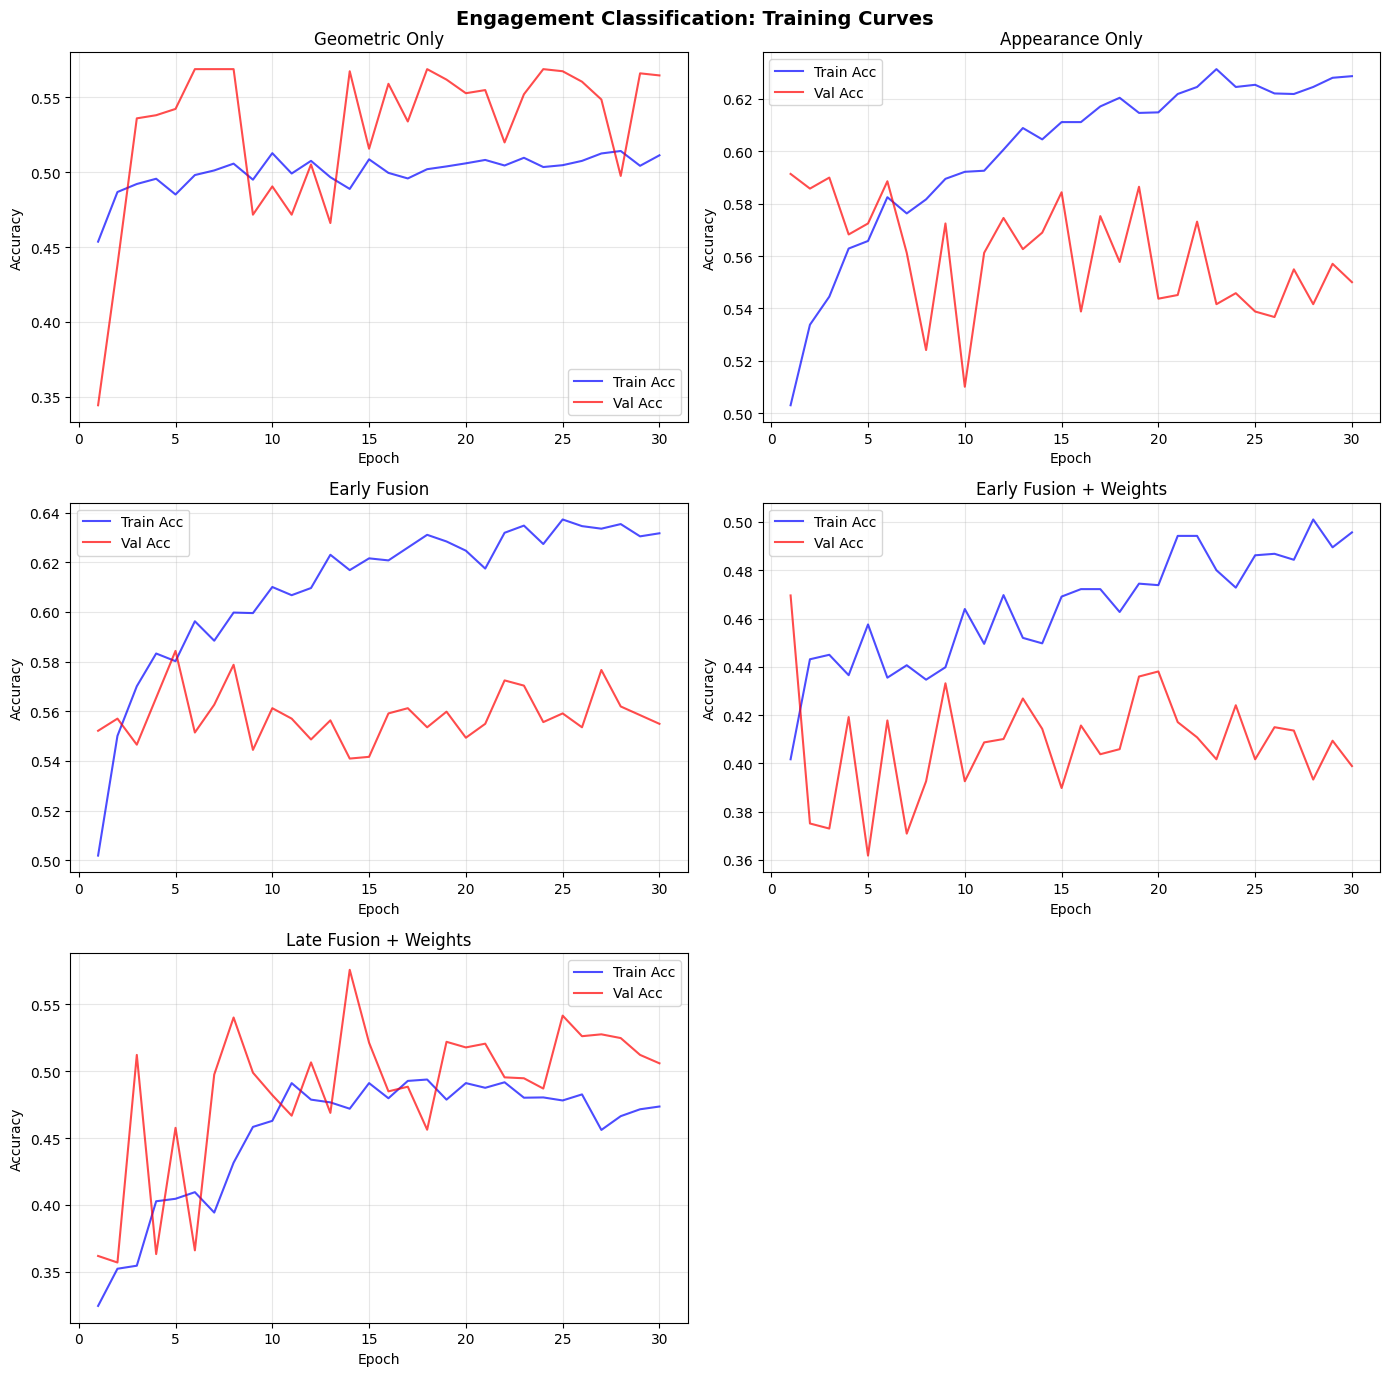

In [ ]:
# --- Training Curves ---
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(f"{TARGET_NAME} Classification: Training Curves", fontsize=14, fontweight="bold")

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx // 2][idx % 2]
    h = res["history"]
    epochs = range(1, len(h["train_acc"]) + 1)
    
    ax.plot(epochs, h["train_acc"], "b-", label="Train Acc", alpha=0.7)
    ax.plot(epochs, h["val_acc"], "r-", label="Val Acc", alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[2][1].set_visible(False)  # hide unused 6th subplot

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

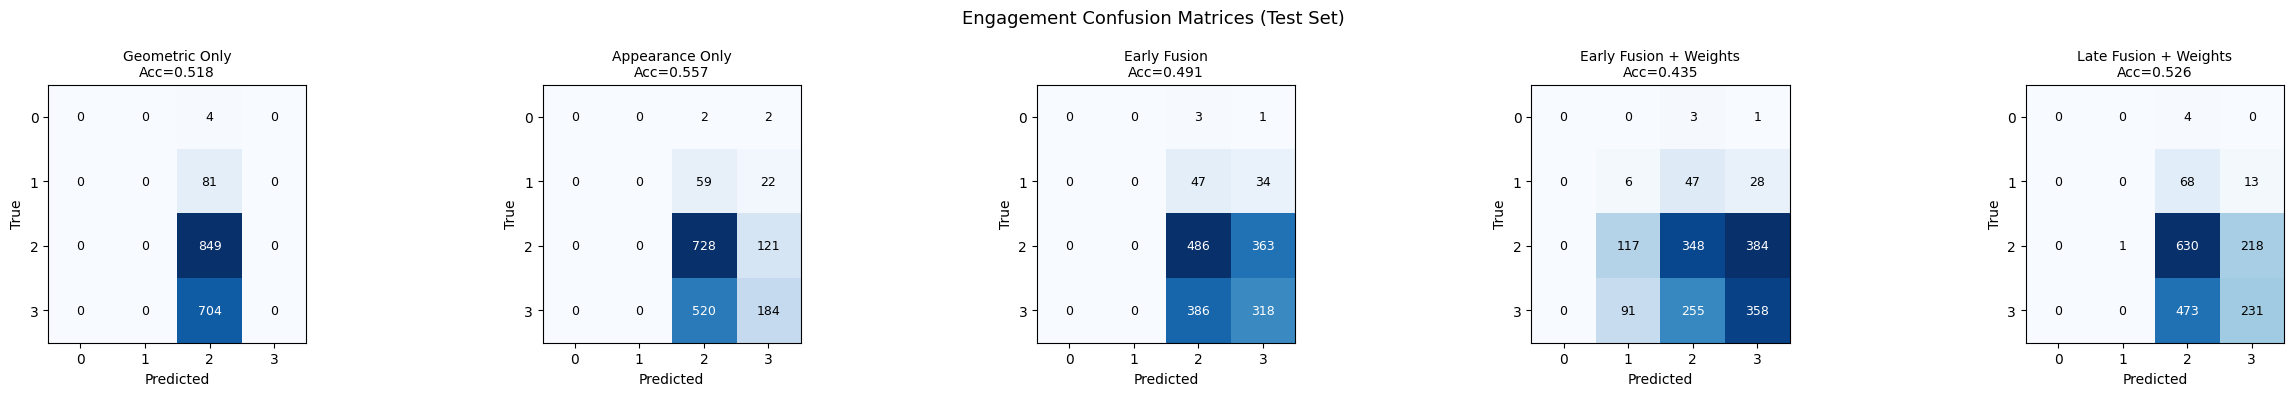

In [ ]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for idx, (name, res) in enumerate(results.items()):
    m = res["metrics"]
    cm = confusion_matrix(m["labels"], m["predictions"])
    
    axes[idx].imshow(cm, cmap="Blues")
    axes[idx].set_title(f"{name}\nAcc={m['accuracy']:.3f}", fontsize=10)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")
    axes[idx].set_xticks(range(4))
    axes[idx].set_yticks(range(4))
    
    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, str(cm[i, j]), ha="center", va="center",
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)

plt.suptitle(f"{TARGET_NAME} Confusion Matrices (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- Classification Reports ---
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print(f"{'='*60}")
    print(res["metrics"]["report"])


Classification Report: Geometric Only
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        81
           2       0.52      1.00      0.68       849
           3       0.00      0.00      0.00       704

    accuracy                           0.52      1638
   macro avg       0.13      0.25      0.17      1638
weighted avg       0.27      0.52      0.35      1638


Classification Report: Appearance Only
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        81
           2       0.56      0.86      0.67       849
           3       0.56      0.26      0.36       704

    accuracy                           0.56      1638
   macro avg       0.28      0.28      0.26      1638
weighted avg       0.53      0.56      0.50      1638


Classification Report: Early Fusion
              